# Week 4 Day 4 - Deep Agents, the top layer

We have reached the top of the stack. A Deep Agent takes the create_agent you met yesterday and wraps it in an opinionated harness, the kind of setup you would otherwise build yourself for serious, multi-step work.

Three things come built in. A planning tool, so the agent can write itself a todo list and work through it. A filesystem, so it can save and reread its working notes rather than holding everything in the conversation. And sub-agents, so it can hand a focused piece of work to a helper with its own clean context. You supply the intent, and the harness supplies the structure.

## When to reach for this

For a quick question with one or two tools, create_agent is the right tool and a Deep Agent would be overkill. Deep Agents earn their keep when a task has many steps, produces artifacts, and benefits from the agent organising its own work. Research and report writing is the classic example, so that is what we will build.

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/stop.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">Before you run this</h2>
            <span style="color:#ff7800;">This lab needs <code>OPENAI_API_KEY</code> and a <code>SERPER_API_KEY</code> for web search. The agent writes its work into a <code>sandbox</code> folder next to this notebook, which we create for it below.
            </span>
        </td>
    </tr>
</table>

In [1]:
# Imports and environment first

import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_community.tools import GoogleSerperRun
from langchain_community.utilities import GoogleSerperAPIWrapper
from deepagents import create_deep_agent
from deepagents.backends import FilesystemBackend

load_dotenv(override=True)

/var/folders/6l/b_60xvys083b1zrv145g64sr0000gn/T/ipykernel_34704/3160738057.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import GoogleSerperRun


True

## A web search tool

We give the agent one tool, and it is one you already know: the off-the-shelf Serper search from `langchain-community` that powered the graph on Day 2. One line and the agent can search the web.

In [2]:
search = GoogleSerperRun(api_wrapper=GoogleSerperAPIWrapper())

## A research agent that plans, searches and writes

Here is our scenario. A company is getting ready to move its sales fleet to electric vehicles, and somebody has to do the homework first: how ready is the public charging network, and which charging providers could a fleet actually rely on? This is the kind of high level task that suits a Deep Agent: open ended enough to need a plan, several searches worth of research and a written briefing as the deliverable.

We point the agent's filesystem at a real `sandbox` folder, so anything it writes appears as a file on disk that we can open afterwards. The agent sees its filesystem at `/`, so when it reports writing to `/charging.md`, that appears as `charging.md` inside our sandbox folder.

It will write itself a todo list, search the web a few times and save a briefing to a file.

In [3]:
sandbox = os.path.abspath("sandbox")
os.makedirs(sandbox, exist_ok=True)

model = ChatOpenAI(model="gpt-5.4-mini")

researcher = create_deep_agent(
    model=model,
    tools=[search],
    system_prompt=(
        "You are a research analyst. Plan your work with your todo tool, "
        "research with the search tool, and write your findings as a tidy markdown briefing to a file."
    ),
    backend=FilesystemBackend(root_dir=sandbox, virtual_mode=True),
)

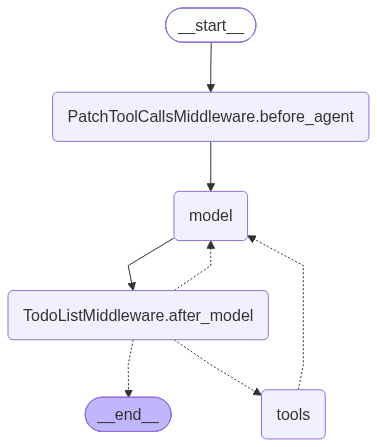

In [4]:
researcher

In [5]:
brief = """
Our company is planning to move its sales fleet to electric vehicles.
Research the public EV charging landscape in the US: find out roughly how many public charging points there are,
and pick out two major charging networks a fleet could rely on.
Write a one page markdown briefing, with a heading and a short section for each, to the file charging.md.
"""

result = researcher.invoke({"messages": [{"role": "user", "content": brief}]})
print(result["messages"][-1].content)

Wrote the briefing to `/charging.md`.


Let us see how it worked. First, the tools it chose to call, which reveal the planning and the file writing. Then we'll go and look in the sandbox folder.

In [6]:
tools_used = [tc["name"] for m in result["messages"] for tc in (getattr(m, "tool_calls", []) or [])]
print("Tools the agent called, in order:")
print(tools_used)

Tools the agent called, in order:
['write_todos', 'google_serper', 'google_serper', 'write_todos', 'write_file', 'write_todos']


## Sub-agents: handing off focused work

A sub-agent is a helper the main agent can delegate to through its `task` tool. The helper runs with its own fresh context, does one job, and reports back a tidy result. This keeps the main agent's attention clear when a task has several independent pieces.

The charging briefing answered whether the fleet switch is feasible. The next question the company will ask is which car to buy, and that splits naturally into independent pieces: each candidate vehicle can be researched on its own. So we define a vehicle researcher sub-agent, and ask the main agent to compare two contenders for the fleet by delegating the research on each.

In [7]:
research_ev_instructions = """
You research one electric vehicle using the search tool and return three concise facts
that a fleet buyer would care about, such as price, range and charging.
"""

overall_instructions = """
You write comparison briefings for a company choosing electric vehicles for its sales fleet.
For each vehicle, delegate the research to your vehicle-researcher sub-agent,
then write a markdown comparison to a file, ending with a clear recommendation.
"""


research_subagent = {
    "name": "vehicle-researcher",
    "description": "Researches a single electric vehicle and returns a short list of facts about it.",
    "system_prompt": research_ev_instructions,
}

lead = create_deep_agent(
    model=model,
    tools=[search],
    system_prompt=overall_instructions,
    subagents=[research_subagent],
    backend=FilesystemBackend(root_dir=sandbox, virtual_mode=True),
)

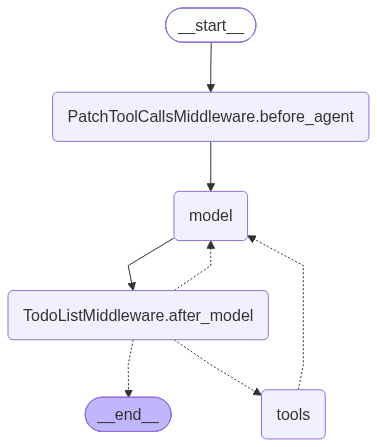

In [8]:
lead

In [9]:
mission = """
Compare the Tesla Model Y and the Ford Mustang Mach-E as candidates for our 100-car sales fleet.
Research each vehicle, then write a short markdown comparison with a recommendation to fleet.md.
"""

result = lead.invoke({"messages": [{"role": "user", "content": mission}]})

In [10]:
tools_used = [tc["name"] for m in result["messages"] for tc in (getattr(m, "tool_calls", []) or [])]
print("Tools the lead agent called:", tools_used)

Tools the lead agent called: ['write_todos', 'task', 'task', 'write_todos', 'write_file', 'write_todos']


### Now go and look at `fleet.md` in the Sandbox folder

## One more thing: Agent Skills

The briefing is good, but we can do better..

deepagents supports Anthropic's Agent Skills pattern, the same `SKILL.md` format that Claude Code uses. A skill is just a folder containing a `SKILL.md` file: YAML frontmatter with a name and a description, followed by markdown instructions. Only the name and description go into the system prompt, and the agent reads the full file with its own `read_file` tool when it decides the skill is relevant. This is called progressive disclosure, and it means you can hand an agent a whole library of skills without flooding its context. Anthropic publishes a library of skills in this format at [github.com/anthropics/skills](https://github.com/anthropics/skills), including the ones behind Claude's own document creation.

We have provided one in the sandbox: [sandbox/skills/fleet-slide/SKILL.md](sandbox/skills/fleet-slide/SKILL.md), the house style of Voltway Research, our fictional analyst brand, for turning a recommendation into a single slide. Open it and have a read before we hand it to an agent.

## A sub-agent that makes the slide

Now for the payoff. We define a slide-maker sub-agent and give it two things the lead agent does not have: the fleet-slide skill, and a `create_slide` tool of its own. The tool wraps a slide template in `slide_kit.py` that handles the design work, with brand colors, logo and layout all taken care of, so the sub-agent's job is to read the briefing, distill the message, and follow the house style. Sub-agents can carry their own tools, models and skills, which is how you build a team of specialists around one lead agent.

In [ ]:
from langchain_core.tools import tool
from slide_kit import build_slide

@tool
def create_slide(title: str, key_points: list[str], recommendation: str) -> str:
    """Create a one-slide PowerPoint in the Voltway Research house style, saved as fleet.pptx."""
    build_slide(title, key_points, recommendation, os.path.join(sandbox, "fleet.pptx"))
    return "Saved the slide to /fleet.pptx"

slide_maker = {
    "name": "slide-maker",
    "description": "Turns a finished recommendation into a one-slide PowerPoint deck.",
    "system_prompt": "You turn research recommendations into slides, following your fleet-slide skill.",
    "tools": [create_slide],
    "skills": ["/skills/"],
}

presenter = create_deep_agent(
    #model=model,
    model="deepseek:deepseek-v4-flash",
    subagents=[slide_maker],
    system_prompt="You prepare research for presentation by delegating to your slide-maker sub-agent.",
    backend=FilesystemBackend(root_dir=sandbox, virtual_mode=True),
)

In [12]:
result = presenter.invoke({"messages": [{"role": "user", "content":
    "Read fleet.md and have a one-slide deck made of its recommendation."}]})
print(result["messages"][-1].content)

Deck created: `/fleet.pptx`

Slide content:
- Title: Tesla Model Y vs. Ford Mustang Mach-E for a 100-Car Sales Fleet
- Recommendation: Choose the Tesla Model Y
- Supporting points:
  - Strongest combination of range, charging convenience, and cargo practicality
  - Should reduce driver downtime and simplify long-route sales travel
  - Mach-E is a solid alternative if local Ford service access is the priority
- Bottom line: Model Y is the better default fleet choice overall


The sandbox now contains `fleet.pptx`. Open it in PowerPoint, Keynote or Google Slides and take a look at a slide that an agent researched, wrote and designed end to end. Our brand happened to be navy and teal; swap the template in `slide_kit.py` and the same agent presents in your company's colors.

## Recap, and where we are heading

You have run a Deep Agent that planned its own work, searched the web, wrote files to disk, delegated to a sub-agent, and turned its findings into a branded PowerPoint slide by following an Agent Skill. That is a lot of capability for very little code, which is what the harness buys you.

Tomorrow's Sidekick deliberately drops back to the create_agent layer, because that is the right level of abstraction for a responsive assistant.

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/exercise.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">Exercise</h2>
            <span style="color:#ff7800;">Give the research agent a second tool. If you add the headful browser tools from yesterday's MCP server, remember they are asynchronous, so you will switch <code>researcher.invoke(...)</code> to <code>await researcher.ainvoke(...)</code> as you did on Day 3. Then open the sandbox folder and read every file the agent wrote for itself along the way. And a stretch challenge: write a skill of your own: a new SKILL.md folder that teaches the slide-maker your house style instead of Voltway's.
            </span>
        </td>
    </tr>
</table>

## Exercise: add another tool to the research agent


⠙⠹⠸Navigating to https://www.tesla.com/modely
Capturing screenshot into playwright_check.png
⠙

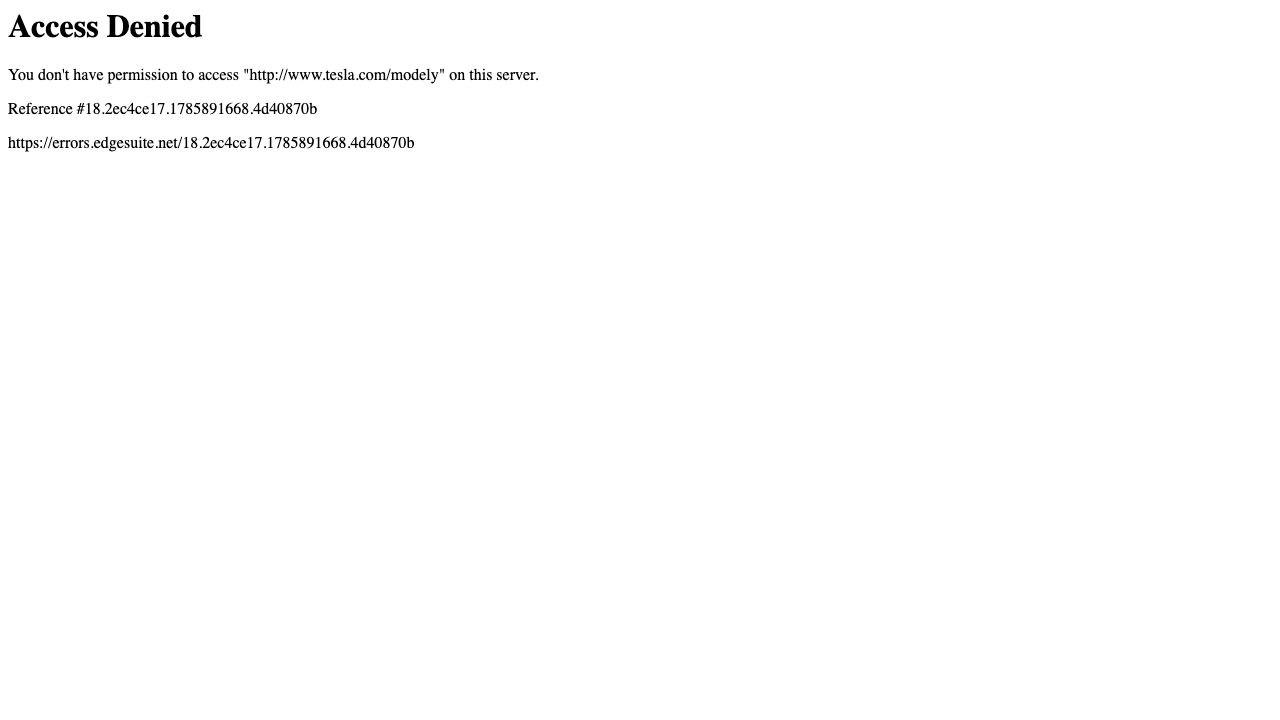

In [37]:
from IPython.display import Image, display

!npx -y playwright@latest screenshot --channel=chrome https://www.tesla.com/modely playwright_check.png
display(Image("playwright_check.png"))

In [57]:
#exercise: add another tool to the research agent
# right noew, there's a researcher deep agent, lead deep agent, and a presenter deep agent.
# The researcher agent has the search tool, which is the Google Serper tool. 
# The lead deep agent also has the search tool, and has 2 subagents that use that tool, and the lead synthesizes the reports. It doesn't use the researcher deep agent.
# The presenter deep agent has no tools, has a slide_maker subagent, which has skills.
# Summary: Use the lead and presenter deep agents only, add the tool to either one. Could use the playwright tool via the MCP server.

from langchain_mcp_adapters.client import MultiServerMCPClient
import os

sandbox_abs = os.path.abspath(sandbox)  # get the real absolute path

client = MultiServerMCPClient({
    "playwright": {
        "transport": "stdio",
        "command": "npx",
        "args": ["-y", "@playwright/mcp@latest", "--isolated", "--output-dir", sandbox_abs],
        #"args": ["-y", "@playwright/mcp@latest", "--isolated", "--output-dir", sandbox_abs, "--snapshot-mode", "none"],
        "cwd": sandbox_abs,   # <-- launch the subprocess itself from inside sandbox
    }
})

browser_tools = await client.get_tools()
print(f"Loaded {len(browser_tools)} browser tools:")
for t in browser_tools:
    print(" -", t.name)

Loaded 24 browser tools:
 - browser_close
 - browser_resize
 - browser_console_messages
 - browser_handle_dialog
 - browser_evaluate
 - browser_file_upload
 - browser_drop
 - browser_find
 - browser_fill_form
 - browser_press_key
 - browser_type
 - browser_navigate
 - browser_navigate_back
 - browser_network_requests
 - browser_network_request
 - browser_run_code_unsafe
 - browser_take_screenshot
 - browser_snapshot
 - browser_click
 - browser_drag
 - browser_hover
 - browser_select_option
 - browser_tabs
 - browser_wait_for


In [42]:
tools_by_name = {t.name: t for t in browser_tools}

nav_result = await tools_by_name["browser_navigate"].ainvoke({"url": "https://news.ycombinator.com"})
print("NAV:", nav_result)

tabs_result = await tools_by_name["browser_tabs"].ainvoke({"action": "list"})
print("TABS:", tabs_result)

shot_result = await tools_by_name["browser_take_screenshot"].ainvoke({"filename": "manual_test.png"})
print("SHOT:", shot_result)

NAV: [{'type': 'text', 'text': "### Ran Playwright code\n```js\nawait page.goto('https://news.ycombinator.com');\n```\n### Page\n- Page URL: https://news.ycombinator.com/\n- Page Title: Hacker News\n### Snapshot\n- [Snapshot](sandbox/page-2026-08-05T01-15-27-465Z.yml)", 'id': 'lc_02647e8e-962b-43e2-a23c-79e82afd30b5'}]
TABS: [{'type': 'text', 'text': '### Result\n- 0: (current) [](about:blank)', 'id': 'lc_8ca768c2-914b-47a0-b421-a74b9e73b368'}]
SHOT: [{'type': 'text', 'text': "### Result\n- [Screenshot of viewport](./manual_test.png)\n### Ran Playwright code\n```js\n// Screenshot viewport and save it as ./manual_test.png\nawait page.screenshot({\n  path: './manual_test.png',\n  scale: 'css',\n  type: 'png'\n});\n```\n### Page\n- Page URL: about:blank", 'id': 'lc_eb609a8b-bf85-4db6-99d4-3d4a9e2ae07d'}]


In [65]:
## use the browser tool to open theofficial car maker's website to get a screenshot of the car that was selected to then put it in the ppt

from langchain.agents.middleware import wrap_tool_call

@wrap_tool_call
async def log_tool_calls(request, handler):
    call = request.tool_call
    print(f"  [middleware] calling {call['name']} with {call['args']}")
    result = await handler(request)  # <-- actual tool execution happens here

    # result is a ToolMessage (or similar) — result.content has the tool's return text
    if call['name'] in ("browser_take_screenshot", "browser_snapshot", "browser_navigate"):
        print(f"  [middleware] {call['name']} RESULT:\n{result.content}\n")

    return result

async with client.session("playwright") as session:
    from langchain_mcp_adapters.tools import load_mcp_tools
    browser_tools = await load_mcp_tools(session)

    browser_agent = create_deep_agent(
        model="deepseek:deepseek-v4-flash",
        tools=browser_tools,
        #system_prompt="You are a web research assistant. Use the browser tools to complete the task, then report clearly.", 
        system_prompt = (
            "You are a web research assistant with browser automation tools.\n\n"
    
            "NAVIGATION:\n"
            "- Always call browser_navigate first, and confirm the returned page URL "
            "matches the intended site (not about:blank) before taking any further action.\n"
            "- Prefer Bing over Google for image searches — Google frequently rate-limits "
            "or bot-challenges automated browsers and returns a 429/CAPTCHA page instead "
            "of real results.\n\n"

            "FINDING CONTENT:\n"
            "- Use browser_find to locate a specific element or piece of text on a page. "
            "Do not call browser_snapshot on content-dense pages like search results pages "
            "(Bing/Google image search, shopping listings, etc.) — these can return massive "
            "accessibility trees that waste context. Only call browser_snapshot when you "
            "specifically need to interact with (click/type into) elements on a simpler page.\n"
            "- If you do call browser_snapshot, always pass a low depth parameter (e.g. depth=3-5) "
            "unless you have a specific reason to need the full tree.\n\n"

            "SCREENSHOTS AND FILES:\n"
            "- When saving files (screenshots, etc.), use a bare filename only, e.g. "
            "'selected_car.png' — do NOT prefix it with 'sandbox/' or any directory path.\n"
            "- After a successful screenshot, trust the tool's own success result. Do NOT "
            "call ls, glob, read_file, or any other tool to verify the file exists — this "
            "wastes calls and context for no benefit.\n"
            "- NEVER call read_file on any image file (.png, .jpg, .jpeg, etc.) for any reason — "
            "including verification, inspection, or confirming content. Reading a binary image "
            "through read_file returns encoded binary data that can consume enormous amounts of "
            "context. Trust the screenshot tool's own success message. If you need to confirm "
            "visual content, do not attempt to — that capability is not available to you.\n"
            "- Never call browser_run_code_unsafe. It cannot access the filesystem or "
            "Node.js globals and will always fail — it is not a valid way to inspect or "
            "verify anything.\n\n"

            "GENERAL:\n"
            "- Be efficient: use the minimum number of tool calls needed to complete the task. "
            "Do not re-verify successful actions or re-navigate to pages you've already confirmed loaded."
        ),
        backend=FilesystemBackend(root_dir=sandbox, virtual_mode=True),
        middleware=[log_tool_calls],
    )
    
    result = await browser_agent.ainvoke({"messages": [{"role": "user", "content": "Read fleet.md and based on which car was selected, first use the browser tool to find an image of that car make and model, specifically the last model released, and then take a screenshot but crop it to fit just one picture of the car, and then and save it as selected_car.png in the current working directory (no leading slash)."}]})
    print(result["messages"][-1].content)

# figure out which car was selected by reading fleet.md
# find the car maker's website
# use the browser tool to open it


  [middleware] calling glob with {'pattern': '**/fleet.md'}
  [middleware] calling read_file with {'file_path': '/fleet.md'}
  [middleware] calling browser_navigate with {'url': 'https://www.bing.com/images/search?q=Tesla+Model+Y+2026'}
  [middleware] browser_navigate RESULT:
[{'type': 'text', 'text': "### Ran Playwright code\n```js\nawait page.goto('https://www.bing.com/images/search?q=Tesla+Model+Y+2026');\n```\n### Page\n- Page URL: https://www.bing.com/images/search?q=Tesla+Model+Y+2026&first=1&cw=1200&ch=829\n- Page Title: Tesla Model Y 2026 - Search Images\n- Console: 9 errors, 0 warnings\n### Events\n- New console entries: console-2026-08-05T03-00-37-613Z.log#L1-L20", 'id': 'lc_91091d26-229b-4962-b247-7b235477ab82'}]

  [middleware] calling browser_evaluate with {'function': "() => {\n  const imgs = Array.from(document.querySelectorAll('a.iusc, a.mfile, div.iusc')).slice(0, 10);\n  const results = [];\n  imgs.forEach(a => {\n    const m = a.getAttribute('m');\n    let info = {};

In [74]:
import importlib
from langchain_core.tools import tool
import slide_kit
importlib.reload(slide_kit)
from slide_kit import build_slide_new

@tool
def create_slide(title: str, key_points: list[str], recommendation: str) -> str:
    """Create a one-slide PowerPoint in the Voltway Research house style, saved as fleet.pptx."""
    build_slide_new(title, key_points, recommendation, os.path.join(sandbox, "fleet.pptx"), os.path.join(sandbox, "selected_car.png"))
    return "Saved the slide to /fleet.pptx"

slide_maker = {
    "name": "slide-maker",
    "description": "Turns a finished recommendation into a one-slide PowerPoint deck.",
    "system_prompt": "You turn research recommendations into slides, following your fleet-slide skill.",
    "tools": [create_slide],
    "skills": ["/skills/"],
}

presenter = create_deep_agent(
    #model=model,
    model="deepseek:deepseek-v4-flash",
    subagents=[slide_maker],
    system_prompt="You prepare research for presentation by delegating to your slide-maker sub-agent.",
    backend=FilesystemBackend(root_dir=sandbox, virtual_mode=True),
)

result = presenter.invoke({"messages": [{"role": "user", "content":
    "Read fleet.md and have a one-slide deck made of its recommendation."}]})
print(result["messages"][-1].content)

Done. The one-slide deck is at **/fleet.pptx**, built from the fleet.md recommendation:

- **Headline:** "Fleet pick: Tesla Model Y"
- **Key points:** ~357 mi EPA range (vs Mach-E ~320 mi), native NACS port + Supercharger access, ~76.2 cu ft cargo with 5 seats
- **Recommendation:** Choose the Model Y for the 100-car fleet to cut driver downtime and simplify long-route travel; Mach-E noted as a solid alternative where local Ford service access matters.


# Exercise: next challenge...